In [42]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
# pip install opencv-python
import cv2

In [43]:
model = keras.applications.MobileNetV2(weights="imagenet")

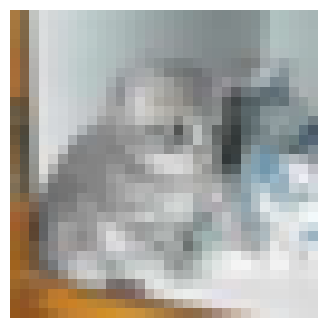

In [44]:
(X_train, y_train), _ = keras.datasets.cifar10.load_data()

idx = np.where(y_train == 3)[0]
img_originel = X_train[idx[5]]

plt.figure(figsize=(4,4))
plt.imshow(img_originel)
plt.axis("off")
plt.show()

In [45]:
img_resized = cv2.resize(img_originel, (224,224))
img_array = np.expand_dims(img_resized, 0)
print(img_array.shape)

(1, 224, 224, 3)


In [46]:
img_preprocessed = keras.applications.mobilenet_v2.preprocess_input(img_array)

In [47]:
# Extraire la sortie de la première couche (conv1)
layer_name = "Conv1"
layer_output = model.get_layer(layer_name).output

# Créer un model qui extrait les features map
features_model = keras.Model(inputs=model.input, outputs=layer_output)

feature_maps = features_model.predict(img_preprocessed)
print(feature_maps.shape[-1])
print(feature_maps.shape)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
32
(1, 112, 112, 32)


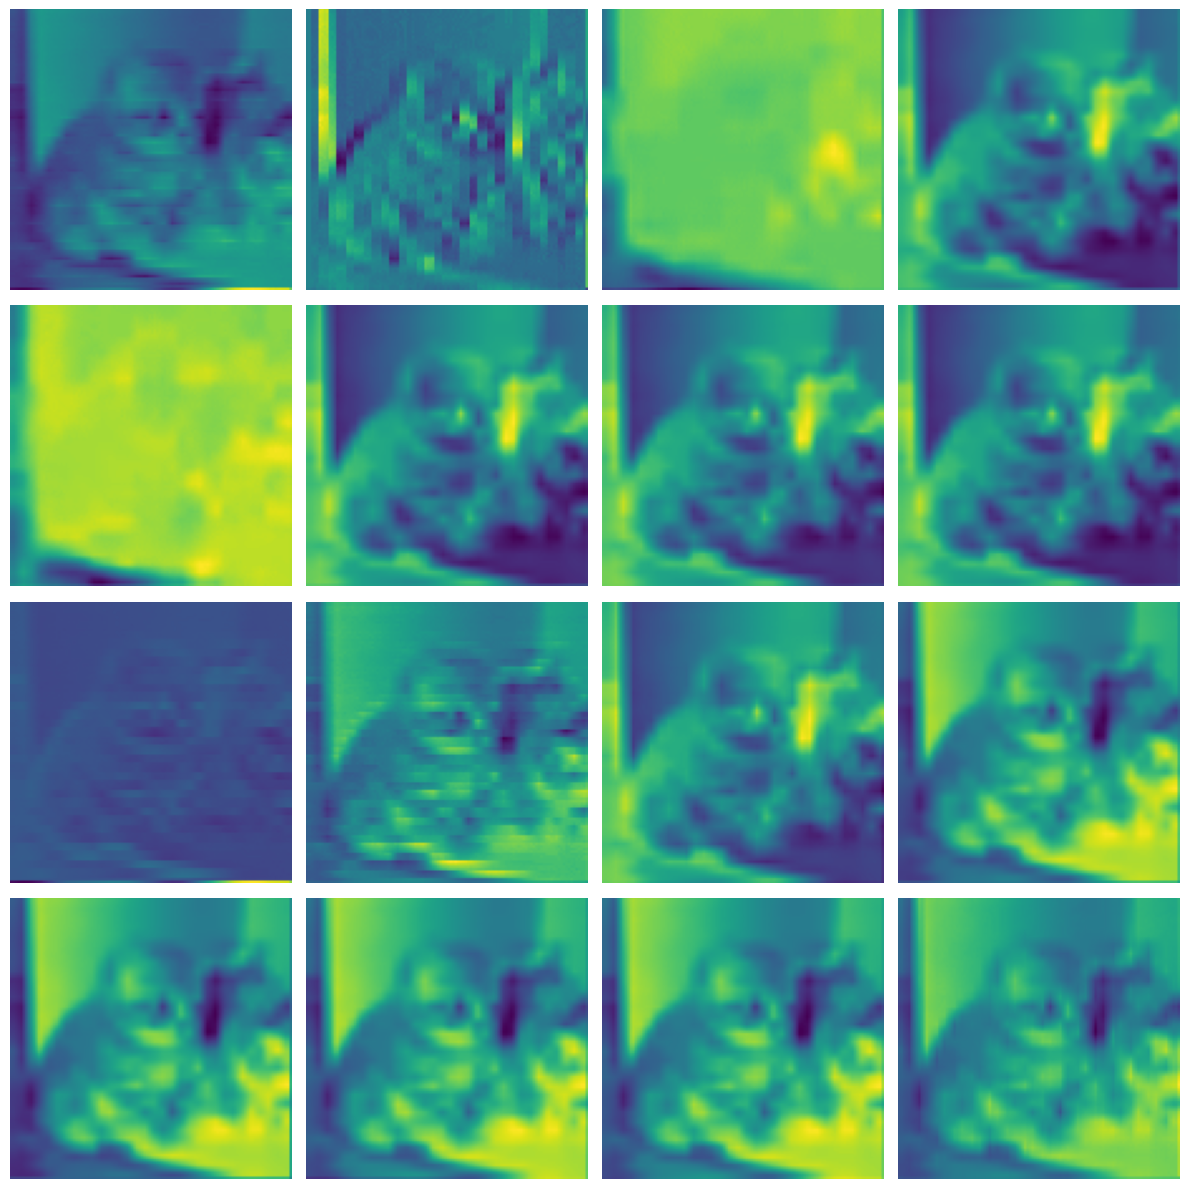

In [48]:
fig, axes = plt.subplots(4, 4, figsize=(12,12))

for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :,:, i], cmap="viridis")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Grad-CAM : Où le modèle regarde t'il ?

In [49]:
preds = model.predict(img_preprocessed)
top_pred_index = np.argmax(preds[0])
top_pred_score = preds[0][top_pred_index]

# Décoder la classe prédite 
decoded = keras.applications.mobilenet_v2.decode_predictions(preds, top=1)[0][0]
print(decoded[1])
print(top_pred_score*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
milk_can
26.032585


In [50]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Modèle grad
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Calculer les gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Gradients de la classe par rapport aux feature maps
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Pooled gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Pondérer les feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normaliser
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

last_output = "out_relu"
heatmap = make_gradcam_heatmap(img_preprocessed, model, last_output)

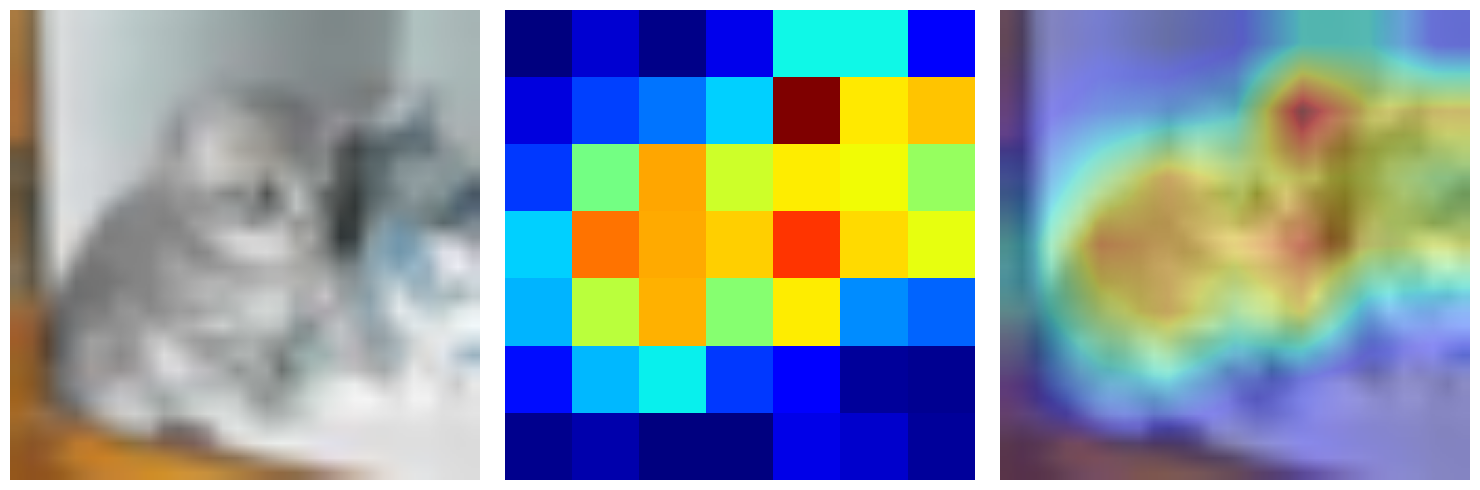

In [51]:
# Superposer la heatmap sur l'image
def superimpose_heatmap(img, heatmap, alpha=0.4):
    # Redimensionner heatmap
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convertir en RGB
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)
    
    # Superposer
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    return superimposed

superimpose_img = superimpose_heatmap(img_resized, heatmap)

fig, axes = plt.subplots(1,3, figsize=(15,5))

axes[0].imshow(img_resized)
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].axis("off")

axes[2].imshow(superimpose_img)
axes[2].axis("off")

plt.tight_layout()
plt.show()